# Generate Report

Generate a report similar to the paper "On the Use of Agentic Coding" using fix-only PRs from `results/` (generated by `classify_fix_prs.py`).

**Produces:**
- `results/report_figures/` — PNG figures
- `results/report.txt` — text summary with tables

In [12]:
%pip install matplotlib seaborn scipy pyarrow fsspec requests

Note: you may need to restart the kernel to use updated packages.


## Imports & Setup

In [13]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as sp_stats

%matplotlib inline

## Paths

In [14]:
DATA_DIR = Path("data_dec2024_feb2026")
OUT_DIR = Path("results")
FIG_DIR = OUT_DIR / "report_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

REPORT_PATH = OUT_DIR / "report.txt"

RESULTS_DIR = Path("results")

## Load Data (Fix PRs Only)

In [ ]:
HF_BASE = "https://huggingface.co/datasets/mabujadallah/GitHub-Agentic-PR-Dataset/resolve/main"

print("Loading fix-only data from Hugging Face ...")
all_prs   = pd.read_parquet(f"{HF_BASE}/fix_prs_only.parquet")

# Exclude open PRs — only keep closed PRs (merged + closed-unmerged) per Watanabe et al.
all_prs = all_prs[all_prs["state"] == "closed"].copy()

agent_prs = all_prs[all_prs["source"] == "agent"].copy()
human_prs = all_prs[all_prs["source"] == "human"].copy()
commits   = pd.read_parquet(f"{HF_BASE}/fix_pr_commits.parquet")
details   = pd.read_parquet(f"{HF_BASE}/fix_pr_commit_details.parquet",
                            columns=["sha", "pr_id", "filename", "additions", "deletions"])


print(f"  Fix Agent PRs (closed) : {len(agent_prs):,}")
print(f"  Fix Human PRs (closed) : {len(human_prs):,}")
print(f"  Commits                : {len(commits):,}")
print(f"  Details                : {len(details):,}")

Loading fix-only data from Hugging Face ...
  Fix Agent PRs : 48,624
  Fix Human PRs : 300,786
  Commits       : 913,847
  Details       : 3,559,124


In [16]:
print("=== all_prs (fix PRs) ===")
display(all_prs.sample(10))

print("\n=== commits ===")
display(commits.sample(10))

print("\n=== details ===")
display(details.sample(10))

=== all_prs (fix PRs) ===


,id,number,title,body,user,user_id,state,created_at,closed_at,merged_at,repo_id,repo_url,repo_name,html_url,is_agent,agent,type,source
213122,3052213401,43686,settings ui: Fix debugger step granularity set...,Closes https://github.com/zed-industries/zed/i...,danilo-leal,67129314,closed,2025-11-27T19:25:10Z,2025-11-27T19:38:53Z,2025-11-27T19:38:53Z,340547520,https://api.github.com/repos/zed-industries/zed,zed-industries/zed,https://github.com/zed-industries/zed/pull/43686,False,human,fix,human
8926,2369153529,2032,build(deps): Bump the patch-updates group with...,Bumps the patch-updates group with 2 updates: ...,dependabot[bot],49699333,closed,2025-03-03T21:34:55Z,2025-03-04T09:58:48Z,None,335571729,https://api.github.com/repos/evstack/ev-node,evstack/ev-node,https://github.com/evstack/ev-node/pull/2032,True,Claude_Code,fix,agent
131786,2801137779,1167,docs: fix icons,## Overview\r\n\r\nThere were bugs with the ic...,ejkorol,65996263,closed,2025-09-05T00:04:22Z,2025-09-05T02:25:12Z,2025-09-05T02:25:12Z,780660899,https://api.github.com/repos/vltpkg/vltpkg,vltpkg/vltpkg,https://github.com/vltpkg/vltpkg/pull/1167,False,human,fix,human
238843,2905024380,10218,Fix: Add frontend and backend component image ...,## 🐛 Problem Description\n\n**Issue:** #10215 ...,balaraj74,199618885,open,2025-10-10T18:20:31Z,None,None,599320067,https://api.github.com/repos/langflow-ai/langflow,langflow-ai/langflow,https://github.com/langflow-ai/langflow/pull/1...,False,human,fix,human
167035,3098545456,1131,fix: cache preview mdflow context in redis,## Summary\n- cache preview context per user/o...,yfge,1186273,closed,2025-12-13T10:08:07Z,2026-01-08T00:54:01Z,None,832552991,https://api.github.com/repos/ai-shifu/ai-shifu,ai-shifu/ai-shifu,https://github.com/ai-shifu/ai-shifu/pull/1131,False,human,fix,human
128023,2475042028,40671,Pin major version of external dependencies - h...,* Pin major version of external dependencies\r...,jayesh-tanna,10186540,closed,2025-04-23T05:05:25Z,2025-04-23T05:11:01Z,2025-04-23T05:11:01Z,4127088,https://api.github.com/repos/Azure/azure-sdk-f...,Azure/azure-sdk-for-python,https://github.com/Azure/azure-sdk-for-python/...,False,human,fix,human
179007,2520754912,1426,fix:lark adapter listeners init problem,## 概述\r\n\r\n实现/解决/优化的内容: \r\nfix: #1425 \r\n#...,dataknocker,7115227,closed,2025-05-15T03:06:03Z,2025-05-15T03:25:38Z,2025-05-15T03:25:38Z,575321313,https://api.github.com/repos/langbot-app/LangBot,langbot-app/LangBot,https://github.com/langbot-app/LangBot/pull/1426,False,human,fix,human
312645,2897651666,26572,24-4-4-hotfix: Make it possible to backup out-...,### Changelog entry <!-- a user-readable short...,snaury,53117,closed,2025-10-08T14:20:16Z,2025-10-08T16:57:00Z,2025-10-08T16:57:00Z,456549280,https://api.github.com/repos/ydb-platform/ydb,ydb-platform/ydb,https://github.com/ydb-platform/ydb/pull/26572,False,human,fix,human
95628,2509456189,9241,fix: add createTextEditorDataMappingButton to ...,**Backport:** https://github.com/shopware/shop...,octo-sts[bot],157150467,closed,2025-05-09T12:03:24Z,2025-05-12T05:52:24Z,2025-05-12T05:52:24Z,131995661,https://api.github.com/repos/shopware/shopware,shopware/shopware,https://github.com/shopware/shopware/pull/9241,False,human,fix,human
44412,2400283562,11429,(fix) Poke sid link to agent was always going ...,## Description\r\n\r\nPoke sid link to agent w...,albandum,1189312,closed,2025-03-18T09:33:07Z,2025-03-18T09:54:29Z,2025-03-18T09:54:29Z,526514610,https://api.github.com/repos/dust-tt/dust,dust-tt/dust,https://github.com/dust-tt/dust/pull/11429,True,Claude_Code,fix,agent



=== commits ===


,sha,pr_id,author,committer,message
92989,376a64f07be075431329d3b87ce3fc23face60b7,3113327845,any-association,any-association,Multilingual [skip ci]
790346,fd1e65b06629d970ecd292e285fc34861850c950,2673722975,CyberROFL,web-flow,24-4-4-hotfix: Storage billing labels (#16741)
299713,97ee188b547a97a85256513c341696b568f423ad,2335260076,jkotas,jkotas,Fix build of windows arm64 crossdac\n\nPartial...
626828,60362d6d15f98d4ddeeecc5917149089fceb0028,2432492496,LFelippeDev,LFelippeDev,feat: Assing terms signup step
405784,caeac0d7e1a394c10cbc25a576c5c4475ac7fc38,2602982868,Ben-Sheppard,Ben-Sheppard,refactor: rename principalIdentifiers map to b...
485270,12ebcf1959e7b5630d12586b78e5c50d82000bd9,3221975174,azure-sdk,azure-sdk,Reset sources for azure-resourcemanager-monito...
512526,52fea73c0010b2fd809b681d1e1713aa70af41da,3294232365,anshugarg15,anshugarg15,fix: correct API reference link for webhook su...
367834,7e40d369aa4ffb9c625411ed56638472cfe9879c,2837940785,elie222,elie222,fix dialog close
2411,b6c3a6230767b726769d31a481b10498173769e4,2592580499,sugyan,sugyan,fix(backend): correct debug flag handling and ...
208493,2ecfc5b2a708cc77d38f974085fe6b6e0823b4b2,2719396503,OneBlue,OneBlue,Various fixes in the WSLA VM logic



=== details ===


,sha,pr_id,filename,additions,deletions
3275239,15edf75a11677978e2e61c46d7598e318194514f,2411317549,turbopack/crates/turbopack-tests/tests/snapsho...,0.0,3.0
1893422,e8d92421e33739aaedd2e13410906ead0a305d7d,3028581495,crates/diesel_models/src/query/payment_method.rs,0.0,16.0
2455157,805969d2b32d701d423ba89edfba81bc6d0c1842,2747578283,receiver/vcenterreceiver/internal/mockserver/c...,1.0,12.0
1613230,1a6fdfef495e115279b4c54a4dfbdf84898ba2b7,2834801041,packages/workshop-utils/src/compile-mdx.server.ts,0.0,13.0
2871575,8f5a85be141e88815fbe32dcd3e6fe3cbc64842a,3121168012,torch/csrc/jit/passes/onnx/cast_all_constant_t...,0.0,10.0
1243840,1f7c53b1ab5d14987b79174feb5255f8bd12eb8f,2660165640,web-version/frontend/node_modules/regjsparser/...,0.0,16.0
2075367,51d89c8ddf3b8b4dec31a4b06d70a47ad83576c4,2675230084,marimo/_cli/cli.py,1.0,1.0
1172333,d024160b83074cbd1d214762472b4c36080acdb1,2251289761,app/client/src/git/store/actions/fetchMergeSta...,1.0,1.0
249733,5d3a3017f94be5965cd3bc5a9bf34479d4419d0e,2571552012,sdk/openai/Azure.AI.OpenAI/src/Generated/Model...,0.0,325.0
1746341,e821827435495905e394f24ebfd2436e03802011,2560259377,src/sentry/scripts/spans/add-buffer.lua,5.0,5.0


## Helper Functions

In [17]:
def word_count(text) -> int:
    if not text or not isinstance(text, str):
        return 0
    return len(text.split())


report_lines: list[str] = []

def section(title: str):
    report_lines.append("")
    report_lines.append("=" * 70)
    report_lines.append(f"  {title}")
    report_lines.append("=" * 70)
    print(f"\n{'=' * 70}\n  {title}\n{'=' * 70}")

def out(line: str = ""):
    report_lines.append(line)
    print(line)

## Dataset Overview

In [ ]:
section("Dataset Overview (Closed Fix PRs Only)")
out(f"Date range         : {all_prs['created_at'].min()[:10]} to {all_prs['created_at'].max()[:10]}")
out(f"Total closed fix PRs : {len(all_prs):,}")
out(f"  Agent fix PRs      : {len(agent_prs):,}")
out(f"  Human fix PRs      : {len(human_prs):,}")
out(f"Repositories       : {all_prs['repo_name'].nunique():,}")
out(f"Total commits      : {len(commits):,}")
out(f"Unique committers  : {commits['author'].nunique():,}")

if "agent" in agent_prs.columns:
    out("\nAgent fix PR breakdown:")
    for agent, cnt in agent_prs["agent"].value_counts().items():
        out(f"  {agent:20s} {cnt:>8,}")


  Dataset Overview (Fix PRs Only)
Date range         : 2024-12-01 to 2026-02-28
Total fix PRs      : 349,410
  Agent fix PRs    : 48,624
  Human fix PRs    : 300,786
Repositories       : 1,616
Total commits      : 913,847
Unique committers  : 31,494

Agent fix PR breakdown:
  Cursor                 20,516
  Claude_Code            16,990
  Copilot                 8,760
  Devin                   2,358


## RQ1 — Fix PR Change Size

**How do Agent fix PRs differ from Human fix PRs in change size?**

In [19]:
section("RQ1: How do Agent fix PRs differ from Human fix PRs in change size?")

# --- Change size metrics from commit details ---
# Aggregate per PR: files changed, lines added, lines deleted
pr_stats = details.groupby("pr_id").agg(
    files_changed=("filename", "nunique"),
    lines_added=("additions", "sum"),
    lines_deleted=("deletions", "sum"),
).reset_index()

agent_ids = set(agent_prs["id"])
human_ids = set(human_prs["id"])

apr_stats = pr_stats[pr_stats["pr_id"].isin(agent_ids)]
hpr_stats = pr_stats[pr_stats["pr_id"].isin(human_ids)]

out("\nChange size (median):")
for metric in ["files_changed", "lines_added", "lines_deleted"]:
    a_med = apr_stats[metric].median() if len(apr_stats) else 0
    h_med = hpr_stats[metric].median() if len(hpr_stats) else 0
    out(f"  {metric:<20s}  APR: {a_med:>8.0f}   HPR: {h_med:>8.0f}")

# --- Description length ---
agent_prs["desc_words"] = agent_prs["body"].apply(word_count)
human_prs["desc_words"] = human_prs["body"].apply(word_count)
out(f"\nPR description length (median words):  APR: {agent_prs['desc_words'].median():.0f}   HPR: {human_prs['desc_words'].median():.0f}")


  RQ1: How do Agent fix PRs differ from Human fix PRs in change size?

Change size (median):
  files_changed         APR:        2   HPR:        2
  lines_added           APR:       28   HPR:       20
  lines_deleted         APR:       10   HPR:        7

PR description length (median words):  APR: 142   HPR: 85


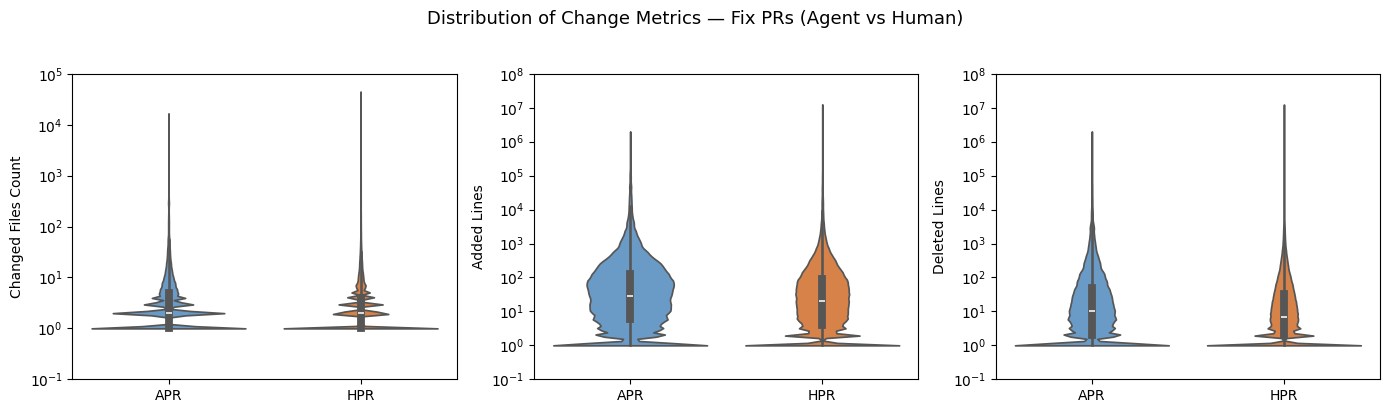

  -> Figure saved: results\report_figures\rq1_change_size.png


In [ ]:
# ── Figure 1: Code Change Size — Box plots on log scale ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ["files_changed", "lines_added", "lines_deleted"]
titles_m = ["Changed Files", "Added Lines", "Deleted Lines"]

for ax, metric, title in zip(axes, metrics, titles_m):
    data = [
        apr_stats[metric].dropna().values,
        hpr_stats[metric].dropna().values,
    ]
    bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
                    widths=0.5, showfliers=False,
                    medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("#5b9bd5")
    bp["boxes"][1].set_facecolor("#ed7d31")
    ax.set_yscale("log")
    ax.set_ylabel(title)
    for i, vals in enumerate(data):
        med = np.median(vals)
        ax.text(i + 1, med * 1.3, f"{med:.0f}", ha="center", fontsize=10, fontweight="bold")

fig.suptitle("Change Size Distribution — Fix PRs (Agent vs Human)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "rq1_change_size.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"  -> Figure saved: {FIG_DIR / 'rq1_change_size.png'}")

# ── Figure 2: PR Description Length ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1.5]})

# Left: bar chart of medians
apr_med = agent_prs["desc_words"].median()
hpr_med = human_prs["desc_words"].median()
bars = axes[0].bar(["APR", "HPR"], [apr_med, hpr_med],
                   color=["#5b9bd5", "#ed7d31"], width=0.5, edgecolor="white")
for bar, val in zip(bars, [apr_med, hpr_med]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                 f"{val:.0f}", ha="center", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Median Word Count")
axes[0].set_title("Median Description Length")

# Right: box plot of full distribution (log scale)
data_desc = [
    agent_prs["desc_words"].clip(lower=1).values,
    human_prs["desc_words"].clip(lower=1).values,
]
bp = axes[1].boxplot(data_desc, labels=["APR", "HPR"], patch_artist=True,
                     widths=0.5, showfliers=False,
                     medianprops=dict(color="black", linewidth=2))
bp["boxes"][0].set_facecolor("#5b9bd5")
bp["boxes"][1].set_facecolor("#ed7d31")
axes[1].set_yscale("log")
axes[1].set_ylabel("Word Count")
axes[1].set_title("Description Length Distribution")

fig.suptitle("PR Description Length — Fix PRs (Agent vs Human)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "rq1_description_length.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"  -> Figure saved: {FIG_DIR / 'rq1_description_length.png'}")

## RQ2 — Acceptance / Rejection Rates

**To what extent are Agent fix PRs rejected?**

In [ ]:
section("RQ2: To what extent are Agent fix PRs rejected?")

def merge_rate(df: pd.DataFrame) -> tuple[int, int, float]:
    merged = df["merged_at"].notna().sum()
    total = len(df)
    return merged, total, merged / total * 100 if total else 0

apr_m, apr_t, apr_r = merge_rate(agent_prs)
hpr_m, hpr_t, hpr_r = merge_rate(human_prs)

out(f"Agent PRs  : {apr_m:,} / {apr_t:,} merged  = {apr_r:.1f}%")
out(f"Human PRs  : {hpr_m:,} / {hpr_t:,} merged  = {hpr_r:.1f}%")

# Chi-squared test on merge rates
contingency = np.array([[apr_m, apr_t - apr_m], [hpr_m, hpr_t - hpr_m]])
if contingency.min() > 0:
    chi2, p_chi, _, _ = sp_stats.chi2_contingency(contingency)
    out(f"Chi-squared test: chi2={chi2:.2f}, p={p_chi:.4f}")
    out(f"  {'Statistically significant' if p_chi < 0.05 else 'Not statistically significant'} at alpha=0.05")

# Merge rate by agent tool
if "agent" in agent_prs.columns:
    out("\nMerge rate by agent tool:")
    for agent_name, grp in agent_prs.groupby("agent"):
        m, t, r = merge_rate(grp)
        out(f"  {agent_name:20s}  {m:>6,} / {t:>6,}  = {r:.1f}%")


  RQ2: To what extent are Agent fix PRs rejected?
Agent PRs  : 38,464 / 48,624 merged  = 79.1%
Human PRs  : 245,530 / 300,786 merged  = 81.6%
Chi-squared test: chi2=175.14, p=0.0000
  Statistically significant at alpha=0.05

Merge rate by agent tool:
  Claude_Code           14,357 / 16,990  = 84.5%
  Copilot                5,059 /  8,760  = 57.8%
  Cursor                17,987 / 20,516  = 87.7%
  Devin                  1,061 /  2,358  = 45.0%


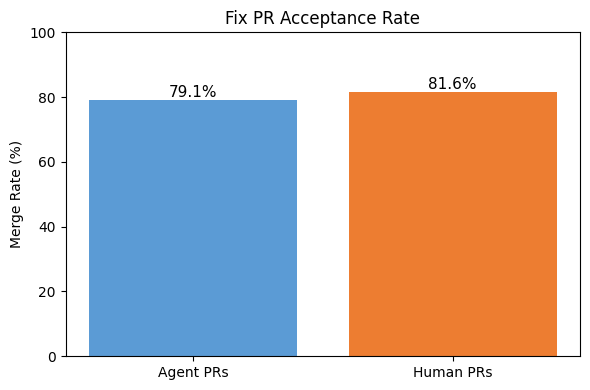


  -> Figure saved: results\report_figures\rq2_merge_rate.png


In [22]:
# Merge rate bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Agent PRs", "Human PRs"], [apr_r, hpr_r], color=["#5b9bd5", "#ed7d31"])
ax.set_ylabel("Merge Rate (%)")
ax.set_title("Fix PR Acceptance Rate")
ax.set_ylim(0, 100)
for bar, val in zip(bars, [apr_r, hpr_r]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{val:.1f}%",
            ha="center", fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / "rq2_merge_rate.png", dpi=150)
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'rq2_merge_rate.png'}")

In [ ]:
# --- Time to merge ---
merge_times = {}
for label, df in [("Agent", agent_prs), ("Human", human_prs)]:
    merged_df = df[df["merged_at"].notna()].copy()
    if len(merged_df) == 0:
        continue
    merged_df["created_dt"] = pd.to_datetime(merged_df["created_at"], utc=True)
    merged_df["merged_dt"] = pd.to_datetime(merged_df["merged_at"], utc=True)
    merged_df["hours_to_merge"] = (merged_df["merged_dt"] - merged_df["created_dt"]).dt.total_seconds() / 3600
    merge_times[label] = merged_df["hours_to_merge"]
    median_h = merged_df["hours_to_merge"].median()
    out(f"\n{label} PRs — median time to merge: {median_h:.2f} hours")

# --- Time to merge box plot ---
fig, ax = plt.subplots(figsize=(7, 5))
data_ttm = [
    merge_times["Agent"].clip(upper=merge_times["Agent"].quantile(0.95)).values,
    merge_times["Human"].clip(upper=merge_times["Human"].quantile(0.95)).values,
]
bp = ax.boxplot(data_ttm, labels=["APR", "HPR"], patch_artist=True,
                widths=0.5, showfliers=False,
                medianprops=dict(color="black", linewidth=2))
bp["boxes"][0].set_facecolor("#5b9bd5")
bp["boxes"][1].set_facecolor("#ed7d31")
for i, vals in enumerate(data_ttm):
    med = np.median(vals)
    ax.text(i + 1, med * 1.15, f"{med:.1f}h", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Hours to Merge")
ax.set_title("Time to Merge — Fix PRs (Agent vs Human)")
fig.tight_layout()
fig.savefig(FIG_DIR / "rq2_time_to_merge.png", dpi=150)
plt.show()
out(f"  -> Figure saved: {FIG_DIR / 'rq2_time_to_merge.png'}")


Agent PRs — median time to merge: 1.42 hours

Human PRs — median time to merge: 5.43 hours


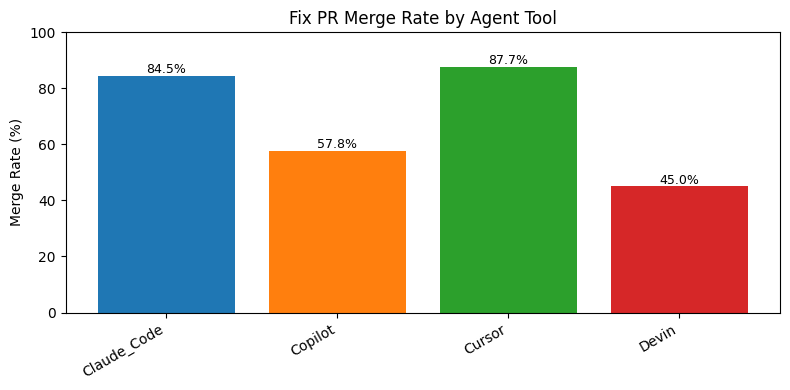

  -> Figure saved: results\report_figures\rq2_merge_rate_by_agent.png


In [24]:
# Merge rate by agent (grouped bar)
if "agent" in agent_prs.columns:
    agent_groups = agent_prs.groupby("agent")
    agents_list = sorted(agent_groups.groups.keys())
    merge_rates = []
    for a in agents_list:
        grp = agent_groups.get_group(a)
        _, _, r = merge_rate(grp)
        merge_rates.append(r)

    fig, ax = plt.subplots(figsize=(8, 4))
    colors = sns.color_palette("tab10", len(agents_list))
    ax.bar(agents_list, merge_rates, color=colors)
    ax.set_ylabel("Merge Rate (%)")
    ax.set_title("Fix PR Merge Rate by Agent Tool")
    ax.set_ylim(0, 100)
    for i, (a, r) in enumerate(zip(agents_list, merge_rates)):
        ax.text(i, r + 1, f"{r:.1f}%", ha="center", fontsize=9)
    plt.xticks(rotation=30, ha="right")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "rq2_merge_rate_by_agent.png", dpi=150)
    plt.show()
    out(f"  -> Figure saved: {FIG_DIR / 'rq2_merge_rate_by_agent.png'}")

In [ ]:
# ── Table 2 (replication): Acceptance and merge time statistics of PRs ──
# Following Watanabe et al.: merged = accepted, closed-but-unmerged = rejected.
# Open PRs already excluded at data loading.

from lifelines.statistics import logrank_test

def compute_row(label, df):
    """Compute stats: merged=accepted, closed-unmerged=rejected."""
    accepted = int(df["merged_at"].notna().sum())
    rejected = int(df["merged_at"].isna().sum())
    total = accepted + rejected
    pct = accepted / total * 100 if total else 0
    merged = df[df["merged_at"].notna()].copy()
    if len(merged):
        merged["hours"] = (
            pd.to_datetime(merged["merged_at"], utc=True)
            - pd.to_datetime(merged["created_at"], utc=True)
        ).dt.total_seconds() / 3600
        med_hours = merged["hours"].median()
    else:
        med_hours = float("nan")
    return [label, f"{accepted:,}", f"{rejected:,}", f"{total:,}", f"{pct:.1f}%", f"{med_hours:.2f}"]

rows = [
    compute_row("APRs", agent_prs),
    compute_row("HPRs", human_prs),
]

# Per-agent breakdown
if "agent" in agent_prs.columns:
    for agent_name in sorted(agent_prs["agent"].unique()):
        rows.append(compute_row(f"  APR – {agent_name}", agent_prs[agent_prs["agent"] == agent_name]))

summary_df = pd.DataFrame(rows, columns=["Category", "#Accepted", "#Rejected", "#Total", "%Acceptance", "Median Time to Merge"])
print("Table 2. Acceptance and merge time statistics of PRs.\n")
display(summary_df)

# ── Chi-squared test on acceptance rates ──
apr_acc = int(agent_prs["merged_at"].notna().sum())
apr_rej = int(agent_prs["merged_at"].isna().sum())
hpr_acc = int(human_prs["merged_at"].notna().sum())
hpr_rej = int(human_prs["merged_at"].isna().sum())
contingency = np.array([[apr_acc, apr_rej], [hpr_acc, hpr_rej]])
chi2, p_chi, _, _ = sp_stats.chi2_contingency(contingency)
print(f"\nChi-squared test (acceptance): χ²={chi2:.2f}, p={p_chi:.6f}")
print(f"  → {'Statistically significant' if p_chi < 0.05 else 'Not significant'} at α=0.05")

# ── Log-rank test on merge times ──
def hours_to_merge(df):
    tmp = df.copy()
    tmp["merged"] = tmp["merged_at"].notna().astype(int)
    tmp["hours"] = (
        pd.to_datetime(tmp["closed_at"], utc=True)
        - pd.to_datetime(tmp["created_at"], utc=True)
    ).dt.total_seconds() / 3600
    return tmp["hours"].values, tmp["merged"].values

apr_time, apr_event = hours_to_merge(agent_prs)
hpr_time, hpr_event = hours_to_merge(human_prs)

lr = logrank_test(apr_time, hpr_time, event_observed_A=apr_event, event_observed_B=hpr_event)
print(f"\nLog-rank test (merge time): test_statistic={lr.test_statistic:.2f}, p={lr.p_value:.6f}")
print(f"  → {'Significant difference' if lr.p_value < 0.05 else 'No significant difference'} in merge times at α=0.05")

Table 2. Acceptance and merge time statistics of PRs.



,Category,#Accepted,#Rejected,#Total,%Acceptance,Median Time to Merge
0,APRs,"38,464","8,493","46,957",81.9%,1.42
1,HPRs,"245,530","43,159","288,689",85.1%,5.43
2,APR – Claude_Code,"14,357","2,343","16,700",86.0%,1.49
3,APR – Copilot,"5,059","2,896","7,955",63.6%,11.56
4,APR – Cursor,"17,987","2,130","20,117",89.4%,0.82
5,APR – Devin,"1,061","1,124","2,185",48.6%,2.18



Chi-squared test (acceptance): χ²=304.96, p=0.000000
  → Statistically significant at α=0.05

Log-rank test (merge time): test_statistic=1199.50, p=0.000000
  → Significant difference in merge times at α=0.05


## RQ3 — Revisions

**What proportion of fix PRs are accepted without revisions?**

In [26]:
section("RQ3: What proportion of fix PRs are accepted without revisions?")

# Count commits per PR
commits_per_pr = commits.groupby("pr_id").size().reset_index(name="num_commits")

apr_commits = commits_per_pr[commits_per_pr["pr_id"].isin(agent_ids)]
hpr_commits = commits_per_pr[commits_per_pr["pr_id"].isin(human_ids)]

# Merged PRs only
merged_agent_ids = set(agent_prs[agent_prs["merged_at"].notna()]["id"])
merged_human_ids = set(human_prs[human_prs["merged_at"].notna()]["id"])

apr_merged_commits = apr_commits[apr_commits["pr_id"].isin(merged_agent_ids)]
hpr_merged_commits = hpr_commits[hpr_commits["pr_id"].isin(merged_human_ids)]

apr_single = (apr_merged_commits["num_commits"] == 1).sum()
hpr_single = (hpr_merged_commits["num_commits"] == 1).sum()
apr_total_merged = len(apr_merged_commits)
hpr_total_merged = len(hpr_merged_commits)

apr_single_pct = apr_single / apr_total_merged * 100 if apr_total_merged else 0
hpr_single_pct = hpr_single / hpr_total_merged * 100 if hpr_total_merged else 0

out(f"Merged without revision (single commit):")
out(f"  Agent PRs : {apr_single:,} / {apr_total_merged:,} = {apr_single_pct:.1f}%")
out(f"  Human PRs : {hpr_single:,} / {hpr_total_merged:,} = {hpr_single_pct:.1f}%")

# Revision commit count distribution (for PRs with >1 commit)
apr_revised = apr_merged_commits[apr_merged_commits["num_commits"] > 1]
hpr_revised = hpr_merged_commits[hpr_merged_commits["num_commits"] > 1]

out(f"\nRevised PRs (>1 commit):")
out(f"  Agent PRs : {len(apr_revised):,}  median commits: {apr_revised['num_commits'].median():.0f}" if len(apr_revised) else "  Agent PRs : 0")
out(f"  Human PRs : {len(hpr_revised):,}  median commits: {hpr_revised['num_commits'].median():.0f}" if len(hpr_revised) else "  Human PRs : 0")

# Mann-Whitney U test on revision counts
if len(apr_revised) > 0 and len(hpr_revised) > 0:
    u_stat, p_val = sp_stats.mannwhitneyu(
        apr_revised["num_commits"], hpr_revised["num_commits"], alternative="two-sided"
    )
    out(f"  Mann-Whitney U: U={u_stat:.0f}, p={p_val:.4f}")
    out(f"  {'Statistically significant' if p_val < 0.05 else 'Not statistically significant'} at alpha=0.05")


  RQ3: What proportion of fix PRs are accepted without revisions?
Merged without revision (single commit):
  Agent PRs : 13,599 / 27,832 = 48.9%
  Human PRs : 89,197 / 178,773 = 49.9%

Revised PRs (>1 commit):
  Agent PRs : 14,233  median commits: 3
  Human PRs : 89,576  median commits: 3
  Mann-Whitney U: U=624564360, p=0.0001
  Statistically significant at alpha=0.05


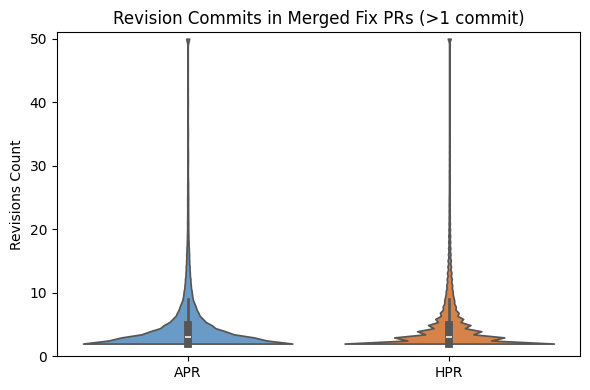


  -> Figure saved: results\report_figures\rq3_revision_commits.png


In [ ]:
# Revision count — box plot
fig, ax = plt.subplots(figsize=(6, 5))
data_rev = []
labels_rev = []
if len(apr_revised):
    data_rev.append(apr_revised["num_commits"].clip(upper=50).values)
    labels_rev.append("APR")
if len(hpr_revised):
    data_rev.append(hpr_revised["num_commits"].clip(upper=50).values)
    labels_rev.append("HPR")
if data_rev:
    bp = ax.boxplot(data_rev, labels=labels_rev, patch_artist=True,
                    widths=0.5, showfliers=False,
                    medianprops=dict(color="black", linewidth=2))
    colors = ["#5b9bd5", "#ed7d31"]
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
    for i, vals in enumerate(data_rev):
        med = np.median(vals)
        ax.text(i + 1, med + 0.5, f"{med:.0f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Revision Commits")
ax.set_title("Revision Commits in Merged Fix PRs")
fig.tight_layout()
fig.savefig(FIG_DIR / "rq3_revision_commits.png", dpi=150)
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'rq3_revision_commits.png'}")

In [28]:
# Revision change size (files, lines) for revised PRs
# For revised PRs, compute stats from commits after the first one
def initial_and_revision_stats(revised_pr_ids: set, commits_df: pd.DataFrame, details_df: pd.DataFrame):
    """Get change stats for initial commit and revision commits separately."""
    pr_commits_ordered = commits_df[commits_df["pr_id"].isin(revised_pr_ids)].copy()
    first_commits = pr_commits_ordered.groupby("pr_id").first().reset_index()
    first_shas = set(first_commits["sha"])

    # Initial commit stats
    init_details = details_df[details_df["sha"].isin(first_shas)]
    init_stats = init_details.groupby("pr_id").agg(
        init_files=("filename", "nunique"),
        init_added=("additions", "sum"),
        init_deleted=("deletions", "sum"),
    ).reset_index()
    init_stats["init_total_changes"] = init_stats["init_added"] + init_stats["init_deleted"]

    # Revision commit stats (all non-first commits)
    rev_shas = set(pr_commits_ordered["sha"]) - first_shas
    rev_details = details_df[details_df["sha"].isin(rev_shas)]
    rev_stats = rev_details.groupby("pr_id").agg(
        rev_files_changed=("filename", "nunique"),
        rev_lines_added=("additions", "sum"),
        rev_lines_deleted=("deletions", "sum"),
    ).reset_index()
    rev_stats["rev_total_changes"] = rev_stats["rev_lines_added"] + rev_stats["rev_lines_deleted"]

    # Merge and compute metric (4): % of code modification vs initial submission
    merged = rev_stats.merge(init_stats[["pr_id", "init_total_changes"]], on="pr_id", how="left")
    merged["pct_modification"] = (
        merged["rev_total_changes"] / merged["init_total_changes"].replace(0, np.nan) * 100
    )
    return merged

apr_rev_ids = set(apr_revised["pr_id"])
hpr_rev_ids = set(hpr_revised["pr_id"])

if apr_rev_ids or hpr_rev_ids:
    apr_rev_stats = initial_and_revision_stats(apr_rev_ids, commits, details) if apr_rev_ids else pd.DataFrame()
    hpr_rev_stats = initial_and_revision_stats(hpr_rev_ids, commits, details) if hpr_rev_ids else pd.DataFrame()

    out("\nRevision effort (median, revised PRs only):")
    out("  Metric (2) - Files changed in revisions:")
    a_med = apr_rev_stats["rev_files_changed"].median() if len(apr_rev_stats) else 0
    h_med = hpr_rev_stats["rev_files_changed"].median() if len(hpr_rev_stats) else 0
    out(f"    APR: {a_med:.0f}   HPR: {h_med:.0f}")

    out("  Metric (3) - Lines added/deleted in revisions:")
    for metric in ["rev_lines_added", "rev_lines_deleted"]:
        a_med = apr_rev_stats[metric].median() if len(apr_rev_stats) else 0
        h_med = hpr_rev_stats[metric].median() if len(hpr_rev_stats) else 0
        out(f"    {metric:<25s}  APR: {a_med:>8.0f}   HPR: {h_med:>8.0f}")

    out("  Metric (4) - % code modification vs initial submission:")
    a_pct = apr_rev_stats["pct_modification"].median() if len(apr_rev_stats) else 0
    h_pct = hpr_rev_stats["pct_modification"].median() if len(hpr_rev_stats) else 0
    out(f"    APR: {a_pct:.1f}%   HPR: {h_pct:.1f}%")


Revision effort (median, revised PRs only):
  Metric (2) - Files changed in revisions:
    APR: 2   HPR: 2
  Metric (3) - Lines added/deleted in revisions:
    rev_lines_added            APR:       18   HPR:       10
    rev_lines_deleted          APR:       10   HPR:        6
  Metric (4) - % code modification vs initial submission:
    APR: 79.6%   HPR: 81.4%


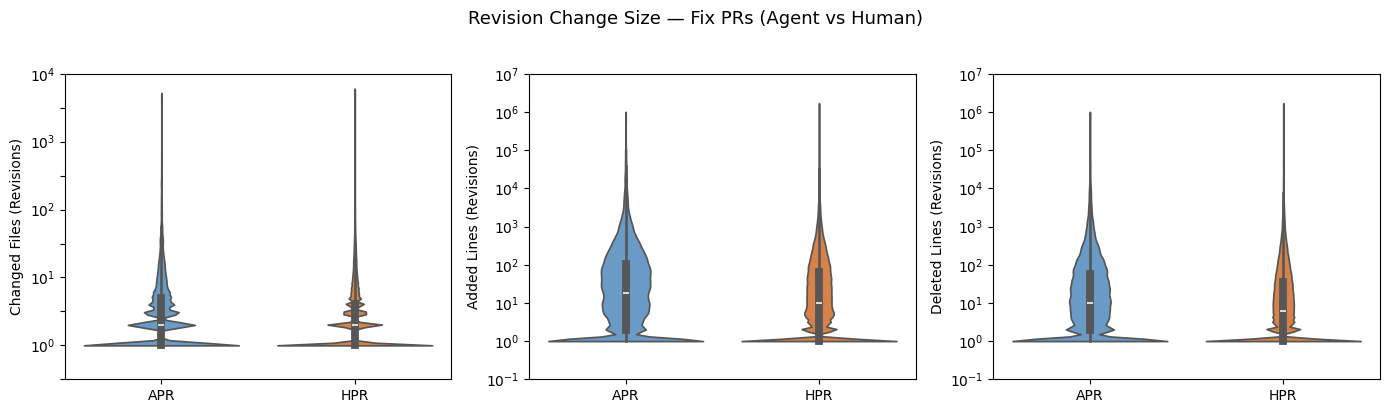

  -> Figure saved: results\report_figures\rq3_revision_change_size.png


In [ ]:
# Revision change size — box plots on log scale
if apr_rev_ids or hpr_rev_ids:
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    rev_metrics = ["rev_files_changed", "rev_lines_added", "rev_lines_deleted"]
    rev_titles = ["Changed Files (Revisions)", "Added Lines (Revisions)", "Deleted Lines (Revisions)"]
    for ax, metric, title in zip(axes, rev_metrics, rev_titles):
        apr_vals = apr_rev_stats[metric].dropna().clip(lower=1).values if len(apr_rev_stats) else np.array([])
        hpr_vals = hpr_rev_stats[metric].dropna().clip(lower=1).values if len(hpr_rev_stats) else np.array([])
        data = [apr_vals, hpr_vals]
        bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
                        widths=0.5, showfliers=False,
                        medianprops=dict(color="black", linewidth=2))
        bp["boxes"][0].set_facecolor("#5b9bd5")
        bp["boxes"][1].set_facecolor("#ed7d31")
        ax.set_yscale("log")
        ax.set_ylabel(title)
        for i, vals in enumerate(data):
            if len(vals):
                med = np.median(vals)
                ax.text(i + 1, med * 1.3, f"{med:.0f}", ha="center", fontsize=10, fontweight="bold")
    fig.suptitle("Revision Change Size — Fix PRs (Agent vs Human)", fontsize=13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "rq3_revision_change_size.png", dpi=150, bbox_inches="tight")
    plt.show()
    out(f"  -> Figure saved: {FIG_DIR / 'rq3_revision_change_size.png'}")

## Additional Statistics

In [30]:
section("Additional Statistics")

# PR state breakdown
out("PR state breakdown:")
for label, df in [("Agent", agent_prs), ("Human", human_prs)]:
    out(f"  {label}:")
    for state, cnt in df["state"].value_counts().items():
        out(f"    {state:12s} {cnt:>8,}")


  Additional Statistics
PR state breakdown:
  Agent:
    closed         46,957
    open            1,667
  Human:
    closed        288,689
    open           12,097


In [31]:
# Monthly trends
all_prs["created_month"] = pd.to_datetime(all_prs["created_at"], utc=True).dt.to_period("M")
monthly = all_prs.groupby(["created_month", "is_agent"]).size().unstack(fill_value=0)
monthly.columns = ["Human", "Agent"] if False in monthly.columns else monthly.columns

out("\nMonthly PR volume:")
out(f"{'Month':<12} {'Agent':>8} {'Human':>8} {'Total':>8}")
out("-" * 40)
for period in monthly.index:
    row = monthly.loc[period]
    agent_val = row.get(True, row.get("Agent", 0))
    human_val = row.get(False, row.get("Human", 0))
    total = agent_val + human_val
    out(f"{str(period):<12} {int(agent_val):>8,} {int(human_val):>8,} {int(total):>8,}")


Monthly PR volume:
Month           Agent    Human    Total
----------------------------------------
2024-12         1,904   14,341   16,245
2025-01         1,937   16,456   18,393
2025-02         2,140   17,474   19,614
2025-03         2,581   19,335   21,916
2025-04         2,570   19,291   21,861
2025-05         3,116   18,789   21,905
2025-06         4,030   19,316   23,346
2025-07         5,011   21,852   26,863
2025-08         3,563   19,083   22,646
2025-09         3,354   20,561   23,915
2025-10         3,246   21,330   24,576
2025-11         3,266   19,851   23,117
2025-12         3,214   20,489   23,703
2026-01         3,863   24,402   28,265
2026-02         4,829   28,216   33,045


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_23776\259854839.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  all_prs["created_month"] = pd.to_datetime(all_prs["created_at"], utc=True).dt.to_period("M")


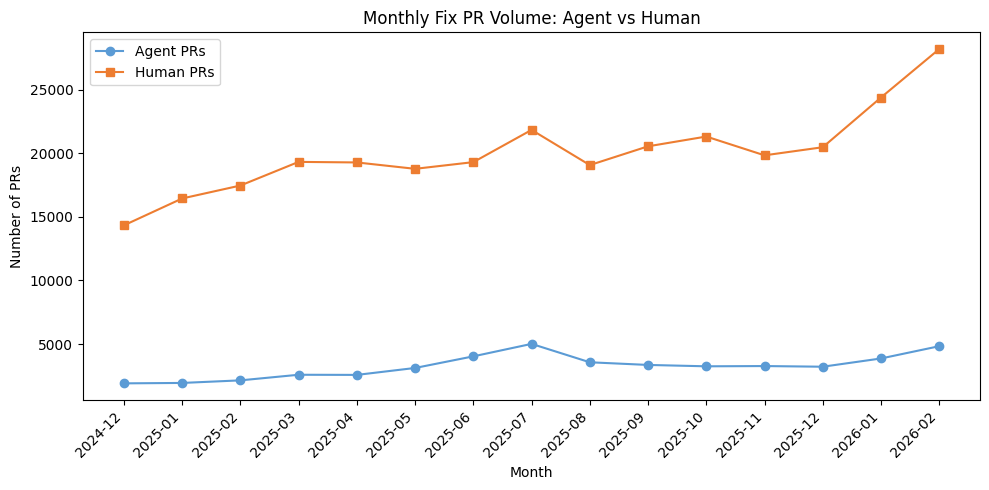


  -> Figure saved: results\report_figures\monthly_trend.png


In [32]:
# Monthly trend chart
fig, ax = plt.subplots(figsize=(10, 5))
months_str = [str(p) for p in monthly.index]
agent_vals = [monthly.loc[p].get(True, monthly.loc[p].get("Agent", 0)) for p in monthly.index]
human_vals = [monthly.loc[p].get(False, monthly.loc[p].get("Human", 0)) for p in monthly.index]
ax.plot(months_str, agent_vals, "o-", label="Agent PRs", color="#5b9bd5")
ax.plot(months_str, human_vals, "s-", label="Human PRs", color="#ed7d31")
ax.set_xlabel("Month")
ax.set_ylabel("Number of PRs")
ax.set_title("Monthly Fix PR Volume: Agent vs Human")
ax.legend()
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "monthly_trend.png", dpi=150)
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'monthly_trend.png'}")

In [33]:
# Top repositories
out("\nTop 10 repos by total PRs:")
top_repos = all_prs["repo_name"].value_counts().head(10)
for repo, cnt in top_repos.items():
    agent_cnt = len(all_prs[(all_prs["repo_name"] == repo) & (all_prs["is_agent"] == True)])
    out(f"  {repo:50s}  total: {cnt:>5,}  agent: {agent_cnt:>5,}")


Top 10 repos by total PRs:
  elastic/kibana                                      total: 8,074  agent:    84
  PostHog/posthog                                     total: 8,034  agent:   134
  StarRocks/starrocks                                 total: 8,031  agent:   166
  getsentry/sentry                                    total: 7,675  agent: 1,578
  vllm-project/vllm                                   total: 5,429  agent:    21
  Expensify/App                                       total: 5,377  agent:     2
  pytorch/pytorch                                     total: 4,757  agent:     9
  microsoft/vscode                                    total: 4,505  agent:   581
  ydb-platform/ydb                                    total: 4,435  agent:    40
  BerriAI/litellm                                     total: 4,154  agent: 1,180


## Save Report

In [34]:
REPORT_PATH.write_text("\n".join(report_lines), encoding="utf-8")
print(f"\nReport saved to {REPORT_PATH}")
print(f"Figures saved to {FIG_DIR}/")
print("Done!")


Report saved to results\report.txt
Figures saved to results\report_figures/
Done!
